In [1]:
import comet_ml
from comet_ml import Experiment

import importlib
import sys
sys.path.append("C:/Users/Valen/Desktop/Laboratorio-2-TAA/utils")

import images_dataset

importlib.reload(images_dataset)

BATCH_SIZE = 32

image_size = (224, 224)
preprocClass = images_dataset.ImagesDataset(image_dir='', audio_dir="../taa-2024-freesound-audio-tagging-v-1/train_curated_resampled/train_curated_resampled", labels_csv="../taa-2024-freesound-audio-tagging-v-1/train_curated.csv", image_size=image_size, batch_size=BATCH_SIZE)
train_dataset, val_dataset, mlb = preprocClass.get_train_and_val_dataset_augmented()

c:\Users\Valen\Desktop\Laboratorio-2-TAA\.conda\lib\site-packages\tqdm_joblib\__init__.py:4: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


Identified 80 unique labels for 4970 files.


100%|██████████| 3976/3976 [00:23<00:00, 169.63it/s]






































  0%|          | 0/994 [00:05<?, ?it/s]


In [2]:
import tensorflow as tf
import keras_tuner as kt
from tensorflow.keras.applications import MobileNet, MobileNetV2

from lwlrap import LwLrap

num_classes = 80


def build_mobilenet(hp, learning_rate=0.01, fine_tune=False, train_upto_layer=8*2 + 5): # train upto two last blocks
    if not fine_tune:
        # Define layers
        preproc = tf.keras.Sequential([
            tf.keras.layers.Rescaling(scale=1./127.5, offset=-1)
        ])
        avg = tf.keras.layers.GlobalAveragePooling2D()
        predict = tf.keras.layers.Dense(num_classes, activation="sigmoid")

        # Define model
        input = tf.keras.Input(shape=image_size + (3,))
        x = preproc(input)
        
        base_model = tf.keras.applications.MobileNetV2(
            input_shape=image_size + (3,),
            include_top=False,
            input_tensor=x
        )
        for layer in base_model.layers:    
            layer.trainable = False
        
        x = avg(base_model.layers[-1].output)
        output = predict(x)
        model = tf.keras.Model(input, output)
        optimizer = tf.keras.optimizers.Nadam(learning_rate=learning_rate)
    else:
        # Load pre-trained model and freez
        model = MobileNetV2(weights='imagenet', include_top=False, input_shape=image_size + (3,))
        for layer in model.layers[:len(model.layers) - train_upto_layer]:
            layer.trainable = False
        for layer in model.layers[len(model.layers) - train_upto_layer:]:
            layer.trainable = True
        # Set lower learning rate as to not overfit
        optimizer = tf.keras.optimizers.Nadam(learning_rate=learning_rate / 10)

    model.compile(loss="binary_crossentropy", optimizer=optimizer, metrics=[LwLrap(num_classes)])
    return model

In [3]:
import tensorflow as tf
import keras_tuner as kt
from tensorflow.keras.models import Model

num_classes = 80

def build_model(hp, learning_rate=1e-3):
    learning_rate = hp.Float("learning_rate", min_value=1e-4, max_value=1e-2, sampling='log')
    dropout_rate = hp.Float("dropout_rate", min_value=0.2, max_value=0.5, step=0.1)
    train_upto_layer = hp.Int("train_upto_layer", min_value=0, max_value=100, step=10)

    base_model = MobileNet(weights='imagenet', include_top=False, input_shape=image_size + (3,))
    
    for layer in base_model.layers[:-train_upto_layer]:
        layer.trainable = False
    
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    
    x = tf.keras.layers.Dropout(dropout_rate)(x)
    x = tf.keras.layers.Dense(num_classes, activation="sigmoid")(x)
    
    model = Model(inputs=base_model.input, outputs=x)
    
    optimizer = tf.keras.optimizers.Nadam(learning_rate=learning_rate)
    model.compile(loss="categorical_crossentropy", optimizer=optimizer, metrics=[LwLrap(num_classes)])
    
    return model

In [4]:
!conda list --export > requirements.txt


In [6]:
api_key = 'RJbMPPcJpbNG60g1DeDQV240w'
experiment = Experiment(
    api_key,
    project_name='baseline-mobilenet',
    workspace="lab2",
    auto_histogram_weight_logging=True,
    auto_histogram_gradient_logging=True,
    auto_histogram_activation_logging=True,
)

experiment.set_name("MobilenetV2 Baseline Pre-train datos aumentados, paciencia 10, fine-tune 2 bloques, lr 1e-3/10, Nadam, 10 epochs")
experiment.add_tag("mobilenetv2")

params={'batch_size':16,
        'epochs':10,
        'learning_rate':1e-3,
        'optimizer':"Nadam",
}

hyperband = kt.Hyperband(
    build_model,
    objective=kt.Objective("val_lwlrap", direction="max"),
    max_epochs=params["epochs"],
    overwrite=True,
    directory="baseline",
    project_name="mobilenetv2",
    seed=42,
    hyperband_iterations=50
)

early = tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET WARNING: Failing to collect the installed pip packages
COMET INFO: Experiment is live on comet.com https://www.comet.com/lab2/baseline-mobilenet/6b89c744f87a4b9eb39ad7ba1123d318



In [7]:
with experiment.train():
    history = hyperband.search(train_dataset, epochs=params["epochs"], validation_data=val_dataset, callbacks=[early])

model = hyperband.get_best_models()[0]
best_hps = hyperband.get_best_hyperparameters(num_trials=1)[0]

Trial 10 Complete [00h 01m 11s]
val_lwlrap: 0.2095109522342682

Best val_lwlrap So Far: 0.579224169254303
Total elapsed time: 00h 12m 27s

Search: Running Trial #11

Value             |Best Value So Far |Hyperparameter
0.00014023        |0.00030693        |learning_rate
0.2               |0.4               |dropout_rate
90                |60                |train_upto_layer
2                 |2                 |tuner/epochs
0                 |0                 |tuner/initial_epoch
2                 |2                 |tuner/bracket
0                 |0                 |tuner/round



COMET WARNING: tensorflow datasets are not currently supported for gradient and activation auto-logging


Epoch 1/2


In [ ]:
model = build_mobilenet(best_hps, fine_tune=True)

history = model.fit(train_dataset, epochs=params["epochs"], validation_data=val_dataset, callbacks=[early])


In [ ]:
print(history)

None


In [ ]:
experiment.end()

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : MobilenetV2 Baseline Pre-train datos aumentados, paciencia 10, fine-tune 2 bloques, lr 1e-3/10, Nadam, 10 epochs
COMET INFO:     url                   : https://www.comet.com/lab2/baseline-mobilenet/f8623e5bb0d04fc1aeb144cf816c6249
COMET INFO:   Others:
COMET INFO:     Name : MobilenetV2 Baseline Pre-train datos aumentados, paciencia 10, fine-tune 2 bloques, lr 1e-3/10, Nadam, 10 epochs
COMET INFO:   Parameters:
COMET INFO:     Nadam_beta_1        : 0.9
COMET INFO:     Nadam_beta_2        : 0.999
COMET INFO:     Nadam_decay         : 0.004
COMET INFO:     Nadam_epsilon       : 1e-07
COMET INFO:     Nadam_learning_rate : 0.01
COMET INFO:     Optimizer

In [ ]:
model = hyperband.get_best_models()[0]
best_hps = hyperband.get_best_hyperparameters(num_trials=1)[0]
experiment.log_parameters(best_hps.values)

with experiment.test():
    loss, lwlrap = model.evaluate(val_dataset)
    metrics = {
        'loss':loss,
        'lwlrap':lwlrap
    }
    experiment.log_metrics(metrics)

model.save("baseline/best_mobilenetv2.keras")
experiment.log_parameters(params)
experiment.log_curve("LwLrap entrenamiento", range(len(history.history["lwlrap"])), history.history["lwlrap"])
experiment.log_curve("LwLrap validacion", range(len(history.history["val_lwlrap"])), history.history["val_lwlrap"])
experiment.log_curve("Perdida entrenamiento", range(len(history.history["loss"])), history.history["loss"])
experiment.log_curve("Perdida validacion", range(len(history.history["val_loss"])), history.history["val_loss"])
experiment.end()

In [ ]:
experiment.end()

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : MobilenetV2 Baseline Pre-train datos aumentados, paciencia 10, fine-tune 2 bloques, lr 1e-3/10, Nadam, 100 epochs
COMET INFO:     url                   : https://www.comet.com/lab2/baseline-mobilenet/74b860d0cd8943f4b49a8c6057c5b998
COMET INFO:   Metrics:
COMET INFO:     test_loss   : 5.315810680389404
COMET INFO:     test_lwlrap : 0.07852150499820709
COMET INFO:   Others:
COMET INFO:     Name : MobilenetV2 Baseline Pre-train datos aumentados, paciencia 10, fine-tune 2 bloques, lr 1e-3/10, Nadam, 100 epochs
COMET INFO:   Parameters:
COMET INFO:     Nadam_beta_1        : 0.9
COMET INFO:     Nadam_beta_2        : 0.999
COMET INFO:     Nadam_decay      

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    mode='min',
    verbose=1
)

history = model.fit(
    train_dataset,
    epochs=1,
    validation_data=val_dataset,
    callbacks=[checkpoint, early_stopping]
)


In [ ]:
experiment.end()

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : MobilenetV2 Baseline Pre-train datos aumentados, paciencia 10, fine-tune 2 bloques, lr 1e-3/10, Nadam, 100 epochs
COMET INFO:     url                   : https://www.comet.com/valenalaniz/baseline-mobilenet/55dcc811ae3e44c4a79b0413327b250a
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     batch_loss [25]           : (5.045989990234375, 5.87459135055542)
COMET INFO:     batch_lwlrap [25]         : (0.05339333787560463, 0.1256791055202484)
COMET INFO:     epoch_duration            : 64.01500000001397
COMET INFO:     loss                      : 5.02834939956665
COMET INFO:     lwlrap                    : 0.12868347764015198
COMET INFO:     val_l

In [ ]:
model = tf.keras.models.load_model("C:/Users/Valen/Desktop/Laboratorio-2-TAA/notebooks/best_model.h5", custom_objects={'lwlrap': LwLrap(num_classes)})

In [ ]:
preprocClassTest = images_dataset.ImagesDataset(image_dir='C:/Users/Valen/Desktop/Laboratorio-2-TAA/data/test_folder', audio_dir="../taa-2024-freesound-audio-tagging-v-1/test/test", labels_csv="", image_size=image_size, batch_size=BATCH_SIZE)

In [ ]:
submission = preprocClass.gen_submission(
        model,
        test_image_dir="C:/Users/Valen/Desktop/Laboratorio-2-TAA/data/val_preproc_logmel",
        image_size=(224, 224),
        batch_size=32,
    )

Found 994 files belonging to 1 classes.
32/32 [==============================] - 6s 180ms/step


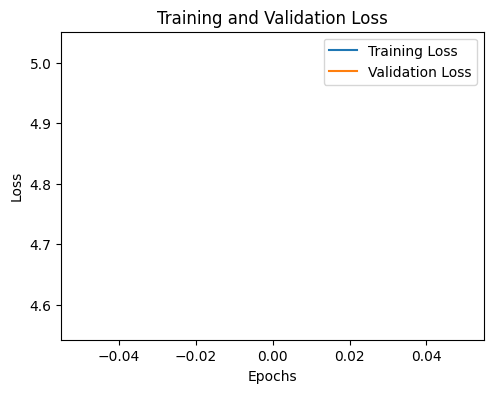

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

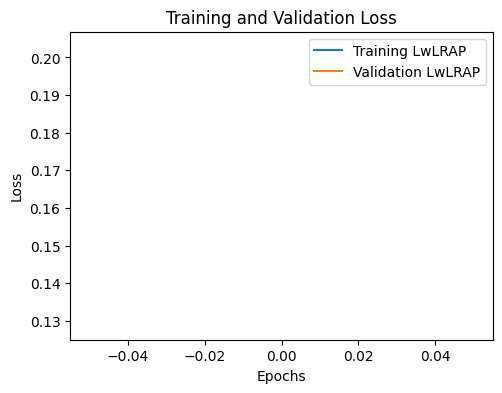

In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['lwlrap'], label='Training LwLRAP')
plt.plot(history.history['val_lwlrap'], label='Validation LwLRAP')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()